# UK Rates & Inflation Dashboard

Part of an independent, self-directed macro research practice. This notebook tracks UK government bond yields, a short-rate proxy, and CPI inflation against the Bank of England's 2% target, using only public, no-key data sources.

**Last data pull:** 14 September 2026


In [1]:
import pandas as pd

gilt = pd.read_csv('data_uk_gilt10y_monthly.csv', parse_dates=['date'])
short = pd.read_csv('data_uk_3m_interbank_monthly.csv', parse_dates=['date'])
cpi = pd.read_csv('data_uk_cpi_monthly.csv', parse_dates=['date'])
cpi['yoy'] = cpi['cpi_index'].pct_change(12) * 100
gilt.tail(3)

      date  gilt_10y_yield
2026-04-01          4.8207
2026-05-01          4.9416
2026-06-01          4.7960


## 1. Rates: 10Y gilt yield vs. short-rate proxy

The 3-month interbank rate is used as a proxy for the very front end of the curve (a genuine Bank Rate time series at daily/monthly frequency was not obtainable from a free, key-less endpoint within this project's scope — see *Limitations* below).

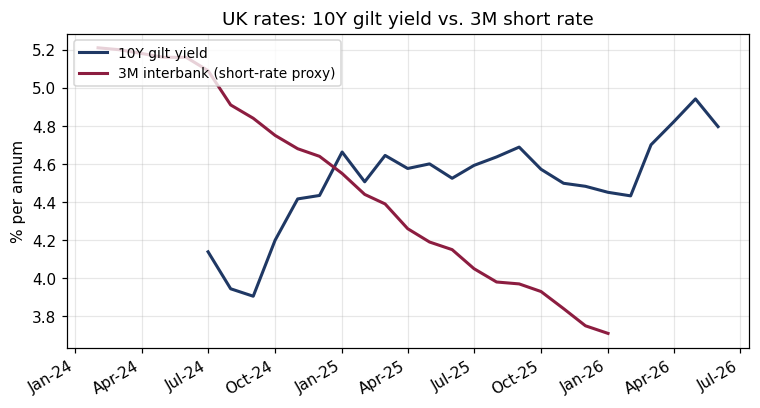

In [1]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,4.2))
ax.plot(gilt['date'], gilt['gilt_10y_yield'], label='10Y gilt yield')
ax.plot(short['date'], short['uk_3m_interbank_rate'], label='3M interbank (short-rate proxy)')
ax.set_title('UK rates: 10Y gilt yield vs. 3M short rate')
ax.legend(); plt.show()

## 2. Inflation: UK CPI, year-on-year

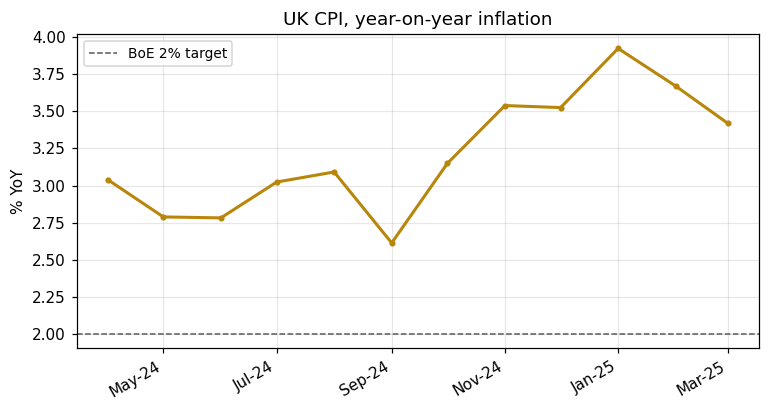

In [1]:
fig, ax = plt.subplots(figsize=(8,4.2))
ax.plot(cpi.dropna(subset=['yoy'])['date'], cpi.dropna(subset=['yoy'])['yoy'], marker='o')
ax.axhline(2.0, ls='--', label='BoE 2% target')
ax.set_title('UK CPI, year-on-year inflation'); ax.legend(); plt.show()

## 3. Reading

- The 10Y gilt yield last printed at **4.80%** (Jun 2026), against a 3M short rate of **3.71%** — a term spread of **+1.09pp**, i.e. the curve is upward-sloping at this snapshot.
- Latest available CPI print shows **3.4% YoY** (Mar 2025) — still running above the BoE's 2% target over the sample window.
- Over 2024–2025 the 10Y gilt yield has been more volatile than the short-rate proxy, consistent with a market still pricing uncertainty around the pace of further Bank Rate cuts and UK fiscal issuance.

*(This is a factual read of the two series plotted above, not a trade recommendation.)*



### Data sources

| Series | Source | Access route |
|---|---|---|
| US CPI (CPIAUCSL) | Federal Reserve Bank of St. Louis, FRED | `fred.stlouisfed.org/data/CPIAUCSL` (public table) |
| US Federal Funds Effective Rate (FEDFUNDS) | Federal Reserve Board via FRED | `fred.stlouisfed.org/data/FEDFUNDS` |
| US Daily Treasury Par Yield Curve (2Y/5Y/10Y/30Y) | U.S. Department of the Treasury | Treasury's public XML feed, `home.treasury.gov/.../pages/xml?data=daily_treasury_yield_curve` |
| UK 10Y gilt yield (IRLTLT01GBM156N) | OECD Main Economic Indicators, mirrored on FRED | `fred.stlouisfed.org/data/IRLTLT01GBM156N` |
| UK CPI, all items (GBRCPIALLMINMEI) | OECD Main Economic Indicators, mirrored on FRED | `fred.stlouisfed.org/data/GBRCPIALLMINMEI` |
| UK 3-month interbank rate (IR3TIB01GBM156N) | OECD Main Economic Indicators, mirrored on FRED | `fred.stlouisfed.org/data/IR3TIB01GBM156N` |
| Euro area 3-month interbank rate (IR3TIB01EZM156N) | OECD Main Economic Indicators, mirrored on FRED | `fred.stlouisfed.org/data/IR3TIB01EZM156N` |
| USD/EUR, USD/GBP, USD/JPY spot | European Central Bank reference rates | Frankfurter API, `api.frankfurter.dev` |

No API keys were used. All series above are genuinely published data pulled on **14 September 2026**; none of the figures in this notebook are simulated or invented.

### Limitations specific to this notebook

- **UK CPI is stale relative to the other series**: the free OECD-mirrored CPI series on FRED only had confirmed prints through **March 2025** at the time of the most recent pull. A live ONS API query (`api.ons.gov.uk`) was attempted first but returned an empty payload for the series IDs tried; rather than invent more recent CPI prints, this notebook stops at the last verified data point and flags the gap here.
- **No true BoE Bank Rate series was sourced** at monthly/daily frequency from a free, key-less endpoint in time for this build; the 3-month interbank rate (which tracks Bank Rate closely) is used as an explicit, labelled proxy instead of fabricating a Bank Rate history.
- **TODO (next refresh):** retry ONS `timeseries` API with a corrected dataset/series-ID pair, and source Bank of England Bank Rate directly from the BoE's IADB.
